In [1]:
#https://github.com/keras-team/keras-io/blob/master/examples/rl/ddpg_pendulum.py

In [190]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [191]:
env = gym.make("Pendulum-v1")
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<PendulumEnv<Pendulum-v1>>>>>

In [192]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

In [220]:
class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        # Formula taken from https://www.wikipedia.org/wiki/Ornstein-Uhlenbeck_process
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )
        # Store x into x_prev
        # Makes next noise dependent on current one
        self.x_prev = x
        return x

    def reset(self):
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)

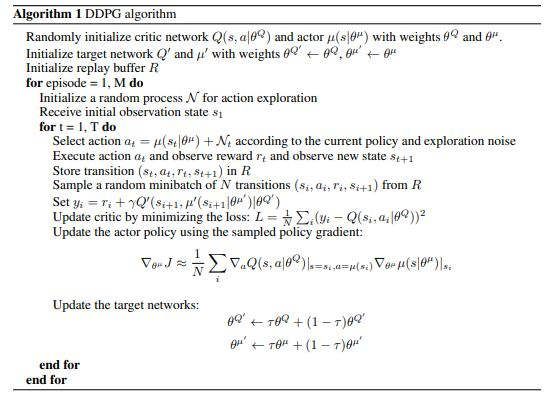

In [221]:
class Buffer:
    def __init__(self, buffer_capacity=100000, batch_size=64):
        # Number of "experiences" to store at max
        self.buffer_capacity = buffer_capacity
        # Num of tuples to train on.
        self.batch_size = batch_size

        # Its tells us num of times record() was called.
        self.buffer_counter = 0

        # Instead of list of tuples as the exp.replay concept go
        # We use different np.arrays for each tuple element
        self.state_buffer = np.zeros((self.buffer_capacity, state_dim))
        self.action_buffer = np.zeros((self.buffer_capacity, action_dim))
        self.done_buffer = np.zeros((self.buffer_capacity, 1))
        self.reward_buffer = np.zeros((self.buffer_capacity, 1))
        self.next_state_buffer = np.zeros((self.buffer_capacity, state_dim))

        self.critic_optim = torch.optim.Adam(critic_model.parameters(), lr =0.001)
        self.actor_optim = torch.optim.Adam(actor_model.parameters(), lr =0.001)

    # Takes (s,a,r,s') observation tuple as input
    def record(self, obs_tuple):
        # Set index to zero if buffer_capacity is exceeded,
        # replacing old records
        index = self.buffer_counter % self.buffer_capacity

        self.state_buffer[index] = obs_tuple[0]
        self.action_buffer[index] = obs_tuple[1]
        self.reward_buffer[index] = obs_tuple[2]
        self.next_state_buffer[index] = obs_tuple[3]
        self.done_buffer[index] = obs_tuple[4]

        self.buffer_counter += 1


    # one epoch, cal loss, and update models
    def update(self, state_batch, action_batch, reward_batch, next_state_batch,done_batch):

        #Q target_action -> 
        with torch.no_grad():
            target_actions = target_actor(next_state_batch)
            y = reward_batch + gamma * (1-done_batch) * target_critic(next_state_batch, target_actions)

        q_values = critic_model(state_batch,action_batch)
        critic_loss = (q_values - y).pow(2).mean()

        self.critic_optim.zero_grad()

        critic_loss.backward()
        self.critic_optim.step()

        #-----------------actor loss

        actions = actor_model(state_batch)
        critic_value = critic_model(state_batch,actions)
        actor_loss = -critic_value.mean()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()


    def learn(self):

        record_range = min(self.buffer_counter, self.buffer_capacity)

        batch_indices = np.random.choice(record_range, self.batch_size)

        

        state_batch = torch.tensor(self.state_buffer[batch_indices], dtype=torch.float32)
        action_batch = torch.tensor(self.action_buffer[batch_indices], dtype=torch.float32)
        reward_batch = torch.tensor(self.reward_buffer[batch_indices], dtype=torch.float32)
        next_state_batch = torch.tensor(self.next_state_buffer[batch_indices], dtype=torch.float32)  
        done_batch = torch.tensor(self.done_buffer[batch_indices], dtype=torch.float32)
        
        self.update(state_batch, action_batch, reward_batch, next_state_batch,done_batch)



        
        

In [222]:
# update target parameters:

def update_target(target, original, tau):

    target_dict = target.state_dict()
    source_dict = original.state_dict()

    for key in target_dict:
        target_dict[key] = tau * source_dict[key] + (1 - tau) * target_dict[key]

    target.load_state_dict(target_dict)

    

In [223]:
# the output for actor here is one as its determinstic 
# ① put scaling *inside* the actor model
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, act_limit):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
            nn.Linear(256, action_dim), nn.Tanh()
        )
        self.act_limit = act_limit

        # --- ✱ critical fix ✱ -----------------------------------------
        # Keras tutorial initialises the last layer uniformly in ±3e-3
        last = self.net[-2]                    # the Linear before tanh
        nn.init.uniform_(last.weight, -3e-3, 3e-3)
        nn.init.uniform_(last.bias,   -3e-3, 3e-3)
        # ---------------------------------------------------------------

    def forward(self, s):
        return self.net(s) * self.act_limit

# as you remember critics modeling Q function and not value

# Why Does the Critic Take an External Action?
# ❗Because: The critic must evaluate arbitrary actions — not just the actor's output.

# We use arbitrary actions — especially from the replay buffer — because:

# 🔀 1. Exploration Needs Randomness
# a = μ(s) + noise


class get_critic(nn.Module):
    def __init__(self, state_dim=state_dim, action_dim=action_dim):
        super(get_critic, self).__init__()

        # State pathway
        self.state_fc1 = nn.Linear(state_dim, 16)
        self.state_fc2 = nn.Linear(16, 32)

        # Action pathway
        self.action_fc1 = nn.Linear(action_dim, 32)

        # Combined pathway
        self.fc1 = nn.Linear(32 + 32, 256)
        self.fc2 = nn.Linear(256, 256)
        self.output = nn.Linear(256, 1)

    def forward(self, state, action):
        s = F.relu(self.state_fc1(state))
        s = F.relu(self.state_fc2(s))

        a = F.relu(self.action_fc1(action))

        x = torch.cat([s, a], dim=1)  # Concatenate along feature dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.output(x)


# ② fix the policy helper
def policy(state_t, noise_obj):
    with torch.no_grad():
        a = actor_model(state_t).cpu()        # correct tensor
    a = a + torch.tensor(noise_obj(), dtype=a.dtype)
    a = torch.clamp(a, lower_bound, upper_bound)
    return a.numpy()


In [224]:
std_dev = 0.2
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

actor_model = Actor(state_dim=state_dim, action_dim = action_dim, act_limit=upper_bound)
critic_model = get_critic()

target_actor = Actor(state_dim=state_dim, action_dim = action_dim, act_limit=upper_bound)
target_critic = get_critic()

#set weights for target initialy
target_actor.load_state_dict(actor_model.state_dict())
target_critic.load_state_dict(critic_model.state_dict())

critic_lr = 0.002
actor_lr = 0.001

total_episodes = 100
# Discount factor for future rewards
gamma = 0.99
# Used to update target networks
tau = 0.005

buffer = Buffer(50000, 64)

In [225]:
# To store reward history of each episode
ep_reward_list = []
# To store average reward history of last few episodes
avg_reward_list = []
for ep in range(total_episodes):
    prev_state, _ = env.reset()
    episodic_reward = 0
    while True:
        t_prev_state = torch.tensor(prev_state,dtype = torch.float32)
        action = policy(t_prev_state, ou_noise)
        state, reward, done, truncated, _ = env.step(action)
        done = done or truncated
        buffer.record((prev_state, action, reward, state,done))
        episodic_reward += reward
        buffer.learn()
        update_target(target_actor, actor_model, tau)
        update_target(target_critic, critic_model, tau)

        if done or truncated:
            break
    ep_reward_list.append(episodic_reward)
    avg_reward = np.mean(ep_reward_list[-40:])
    print("Episode * {} * Avg Reward is ==> {}".format(ep, avg_reward))
    avg_reward_list.append(avg_reward)

        

Episode * 0 * Avg Reward is ==> -1672.0330999008245
Episode * 1 * Avg Reward is ==> -1653.1276318343453
Episode * 2 * Avg Reward is ==> -1389.0049666991147
Episode * 3 * Avg Reward is ==> -1330.6599130374325
Episode * 4 * Avg Reward is ==> -1329.9763529805018
Episode * 5 * Avg Reward is ==> -1287.1727933766813
Episode * 6 * Avg Reward is ==> -1287.980552864349
Episode * 7 * Avg Reward is ==> -1257.5229422029665
Episode * 8 * Avg Reward is ==> -1236.1002687601772
Episode * 9 * Avg Reward is ==> -1272.6088190228736
Episode * 10 * Avg Reward is ==> -1269.2991810205074
Episode * 11 * Avg Reward is ==> -1252.9922369600554
Episode * 12 * Avg Reward is ==> -1234.6810990504734
Episode * 13 * Avg Reward is ==> -1254.3946587691519
Episode * 14 * Avg Reward is ==> -1230.6021898754727
Episode * 15 * Avg Reward is ==> -1234.6266841848192
Episode * 16 * Avg Reward is ==> -1225.0439881439186
Episode * 17 * Avg Reward is ==> -1228.5579795439626
Episode * 18 * Avg Reward is ==> -1233.8616836274682
Epis

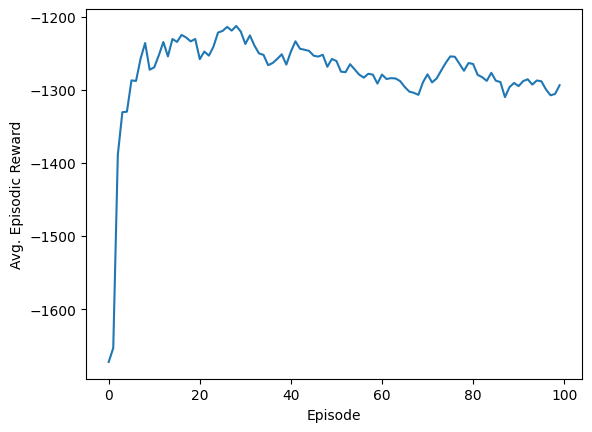

In [226]:
plt.plot(avg_reward_list)
plt.xlabel("Episode")
plt.ylabel("Avg. Episodic Reward")
plt.show()